In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pytorch version:", torch.__version__)

Pytorch version: 2.11.0+cu128


In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load Dataset
cancer = load_breast_cancer()

# Create DataFrame with Feature Names
df = pd.DataFrame(
    cancer.data,
    columns = cancer.feature_names
)

# Add target column
df["target"] = cancer.target

# Dataset shape
print("Shape:", df.shape)

# Class distribution
print("\nClass distribution:")
print(f"Malignant (0): {(df['target'] == 0).sum()}")
print(f"Benign(1): {(df['target'] == 1).sum()}")

# Check for Null values
print("\nNull Values:")
print(df.isnull().sum().sum())

# First 5 rows
print("\nFirst 5 rows:")
display(df.head())

Shape: (569, 31)

Class distribution:
Malignant (0): 212
Benign(1): 357

Null Values:
0

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Split features (X) and labels (y)
X = df.drop("target", axis = 1)
y = df["target"]

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

# Standardize features using training data only
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# Convert to PyTorch float tensors
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train.values, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.float32)

# Print tensor shapes
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: torch.Size([455, 30])
X_test shape:  torch.Size([114, 30])
y_train shape:  torch.Size([455])
y_test shape:  torch.Size([114])


In [4]:
# Create TensorDataset objects
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

# Print number of batches
print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 15
Number of test batches: 4


In [5]:
# Define the neural network
class BreastCancerNet(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(30, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(32, 16),
        nn.ReLU(),

        nn.Linear(16, 1),
        nn.Sigmoid(),
    )

  def forward(self, x):
    return self.network(x)

# Instantiate the model
model = BreastCancerNet()

# Print model architecture
print(model)

# Manual parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTotal parameters:", total_params)
print("Trainable parameters:", trainable_params)

BreastCancerNet(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Total parameters: 4801
Trainable parameters: 4801


In [6]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Loss function
criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr = 1e-3,
    weight_decay = 1e-4
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.5,
    patience = 5
)

# Print initial learning rate
print("Initial learning rate: ", optimizer.param_groups[0],["lr"])

Initial learning rate:  {'params': [Parameter containing:
tensor([[-0.1393,  0.1309,  0.1191,  ...,  0.0879,  0.0244, -0.0539],
        [ 0.0743,  0.1280, -0.0611,  ...,  0.1192,  0.0259,  0.1206],
        [-0.1550, -0.0352,  0.0430,  ..., -0.0196,  0.1635, -0.0319],
        ...,
        [ 0.1394, -0.0658,  0.0915,  ...,  0.0226,  0.1191, -0.0540],
        [ 0.0061,  0.1308, -0.0732,  ...,  0.1669, -0.0836,  0.1392],
        [-0.0384,  0.1305,  0.0313,  ...,  0.0970, -0.1536,  0.1396]],
       requires_grad=True), Parameter containing:
tensor([ 0.0050,  0.1261, -0.0602, -0.1462, -0.0907,  0.0813, -0.0629,  0.1394,
         0.1226,  0.0212, -0.1573,  0.0181,  0.1022,  0.1465, -0.1677,  0.0721,
        -0.0098,  0.0183, -0.0646,  0.1271,  0.0976,  0.0553, -0.0268, -0.0863,
         0.0924,  0.0921, -0.0913, -0.1122, -0.1149,  0.0200, -0.0896,  0.1620,
        -0.0428, -0.0291,  0.1721, -0.1071, -0.1308, -0.0906, -0.0933, -0.0933,
        -0.0657,  0.1693, -0.1802, -0.1102,  0.0073, -0.11

In [7]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Store metrics for each epoch
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 100

for epoch in range(num_epochs):

    # Training
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        optimizer.step()

        # Track loss
        running_train_loss += loss.item() * X_batch.size(0)

        # Track accuracy
        predictions = (y_pred >= 0.5).float()
        train_correct += (predictions == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    # Validation
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            # Forward pass
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            # Track loss
            running_val_loss += loss.item() * X_batch.size(0)

            # Track accuracy
            predictions = (y_pred >= 0.5).float()
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    # Learning-rate scheduler
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Print summary every 10 epochs
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1:3d}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"LR: {current_lr:.6f}"
        )

print("\nTraining complete!")
print("Device:", device)

Epoch [ 10/100] | Train Loss: 0.1174 | Val Loss: 0.1220 | Train Acc: 0.9802 | Val Acc: 0.9649 | LR: 0.001000
Epoch [ 20/100] | Train Loss: 0.0735 | Val Loss: 0.0851 | Train Acc: 0.9758 | Val Acc: 0.9737 | LR: 0.001000
Epoch [ 30/100] | Train Loss: 0.0438 | Val Loss: 0.0672 | Train Acc: 0.9912 | Val Acc: 0.9737 | LR: 0.000500
Epoch [ 40/100] | Train Loss: 0.0721 | Val Loss: 0.0614 | Train Acc: 0.9714 | Val Acc: 0.9825 | LR: 0.000500
Epoch [ 50/100] | Train Loss: 0.0396 | Val Loss: 0.0600 | Train Acc: 0.9912 | Val Acc: 0.9912 | LR: 0.000250
Epoch [ 60/100] | Train Loss: 0.0668 | Val Loss: 0.0591 | Train Acc: 0.9758 | Val Acc: 0.9737 | LR: 0.000250
Epoch [ 70/100] | Train Loss: 0.0670 | Val Loss: 0.0589 | Train Acc: 0.9758 | Val Acc: 0.9737 | LR: 0.000063
Epoch [ 80/100] | Train Loss: 0.0788 | Val Loss: 0.0585 | Train Acc: 0.9736 | Val Acc: 0.9737 | LR: 0.000016
Epoch [ 90/100] | Train Loss: 0.0477 | Val Loss: 0.0628 | Train Acc: 0.9802 | Val Acc: 0.9649 | LR: 0.000008
Epoch [100/100] | T

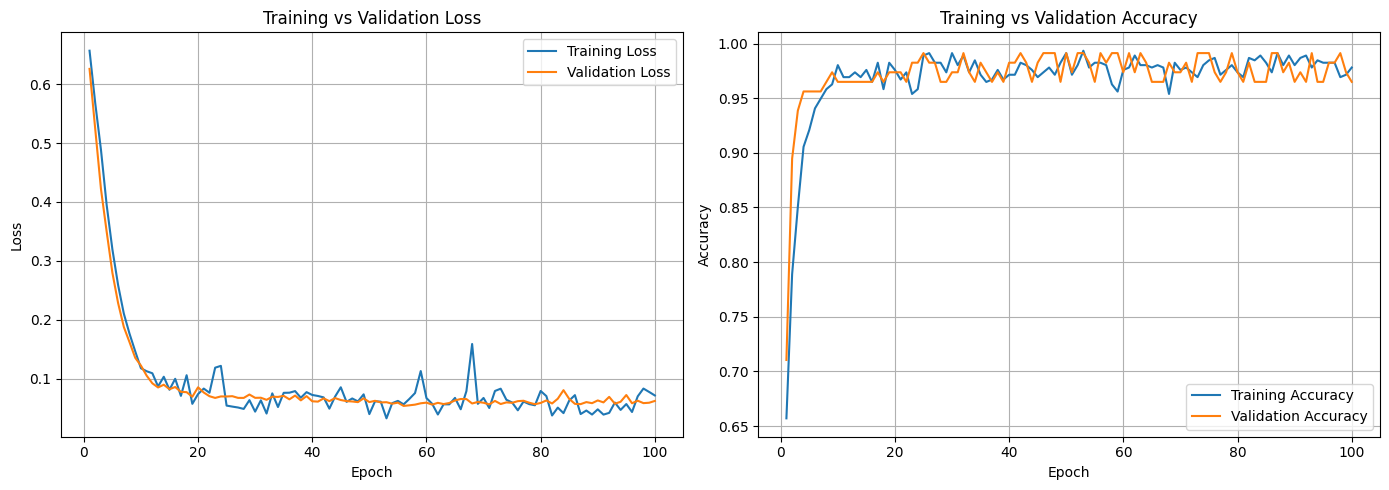

In [8]:
# Create epoch values
epochs = range(1, len(train_losses) + 1)

# Create two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Loss plot
# -------------------------
axes[0].plot(epochs, train_losses, label="Training Loss")
axes[0].plot(epochs, val_losses, label="Validation Loss")

axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# -------------------------
# Accuracy plot
# -------------------------
axes[1].plot(epochs, train_accuracies, label="Training Accuracy")
axes[1].plot(epochs, val_accuracies, label="Validation Accuracy")

axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Test Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

AUC-ROC Score: 0.9977


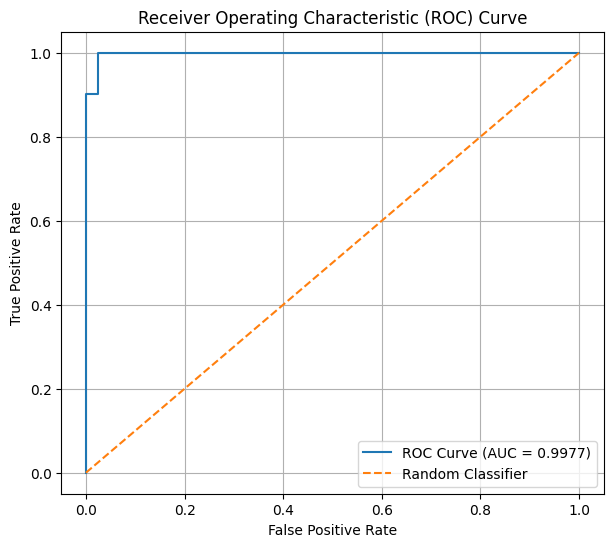

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve

# Evaluate the model on the test set
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Get predicted probabilities
        probabilities = model(X_batch).squeeze(1)

        # Convert probabilities to class predictions
        predictions = (probabilities >= 0.5).long()

        all_labels.extend(y_batch.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to NumPy arrays
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

# -------------------------
# Classification metrics
# -------------------------
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Malignant", "Benign"]
    )
)

# -------------------------
# AUC-ROC
# -------------------------
auc_roc = roc_auc_score(all_labels, all_probabilities)
print(f"AUC-ROC Score: {auc_roc:.4f}")

# -------------------------
# ROC Curve
# -------------------------
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_roc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()

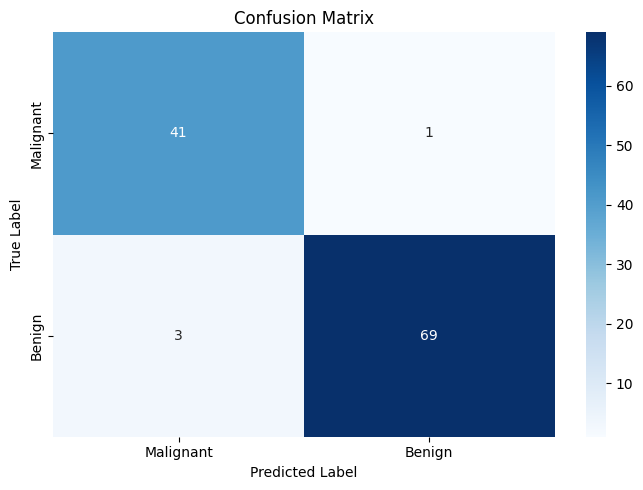

In [12]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [13]:
# Select 5 random samples from the test set
random_indices = np.random.choice(len(X_test), size=5, replace=False)

# Put model in evaluation mode
model.eval()

print(f"{'Sample':<10}{'Probability':<15}{'Predicted':<15}{'Actual':<15}")
print("-" * 55)

with torch.no_grad():
    for i, idx in enumerate(random_indices, start=1):
        # Get one sample
        X_sample = X_test[idx].unsqueeze(0).to(device)
        y_actual = y_test[idx].item()

        # Get probability output
        probability = model(X_sample).item()

        # Convert probability to predicted label
        predicted = 1 if probability >= 0.5 else 0

        predicted_label = "Benign" if predicted == 1 else "Malignant"
        actual_label = "Benign" if y_actual == 1 else "Malignant"

        print(
            f"{i:<10}"
            f"{probability:<15.6f}"
            f"{predicted_label:<15}"
            f"{actual_label:<15}"
        )

Sample    Probability    Predicted      Actual         
-------------------------------------------------------
1         0.003870       Malignant      Malignant      
2         0.997386       Benign         Benign         
3         0.004545       Malignant      Malignant      
4         0.001790       Malignant      Malignant      
5         0.988927       Benign         Benign         
